In [27]:
import pandas as pd
import numpy as np

In [28]:
df=pd.read_csv('dataset/Train_mixed.csv')
df.head()

,Number,Survived,Ticket,Cabin
0,4,1,A/5 21171,C85
1,R,0,PC 17599,NaN
2,6,1,STON/O2. 3101282,C123
3,8,1,113803,NaN
4,4,0,373450,NaN


In [29]:
df['Number'].unique()

array(['4', 'R', '6', '8', 'E', '3', 'U', '7', '9', 'y', 'p', 'k', '2',
       '5'], dtype=object)

In [30]:
df["Number"].value_counts()

Number
4    3
6    2
3    2
8    2
7    2
R    1
E    1
U    1
9    1
y    1
p    1
k    1
2    1
5    1
Name: count, dtype: int64

# 1. Extract Numerical Part

In [31]:
df['number_numer']=pd.to_numeric(df['Number'],errors='coerce',downcast='integer')

# 2. Extract categorical part

In [32]:
df['number_categ']=np.where(df['number_numer'].isnull(),df['Number'],np.nan)
df.sample(10)

,Number,Survived,Ticket,Cabin,number_numer,number_categ
4,4,0,373450,NaN,4.0,NaN
15,7,0,112053,C23 C25 C27,7.0,NaN
6,3,1,17463,NaN,3.0,NaN
8,7,1,347742,NaN,7.0,NaN
7,U,0,349909,U,NaN,U
5,E,0,330877,E46,NaN,E
9,9,1,237736,B57 B59 B63 B66,9.0,NaN
17,4,0,111369,NaN,4.0,NaN
13,2,1,349909,NaN,2.0,NaN
3,8,1,113803,NaN,8.0,NaN


# For Cabin

In [35]:
df['Cabin_num']=df['Cabin'].str.extract('(\d+)') # Capture numerical data
df['Cabin_cat']=df['Cabin'].str[0]  # Capture the first letter
df

,Number,Survived,Ticket,Cabin,number_numer,number_categ,Cabin_num,Cabin_cat
0,4,1,A/5 21171,C85,4.0,NaN,85,C
1,R,0,PC 17599,NaN,NaN,R,NaN,NaN
2,6,1,STON/O2. 3101282,C123,6.0,NaN,123,C
3,8,1,113803,NaN,8.0,NaN,NaN,NaN
4,4,0,373450,NaN,4.0,NaN,NaN,NaN
5,E,0,330877,E46,NaN,E,46,E
6,3,1,17463,NaN,3.0,NaN,NaN,NaN
7,U,0,349909,U,NaN,U,NaN,U
8,7,1,347742,NaN,7.0,NaN,NaN,NaN
9,9,1,237736,B57 B59 B63 B66,9.0,NaN,57,B


<Axes: xlabel='Cabin_cat'>

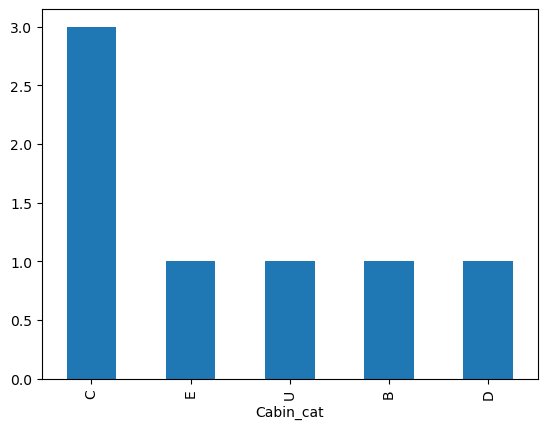

In [36]:
df['Cabin_cat'].value_counts().plot(kind='bar')

# for Ticket

In [37]:
# Extract the Last bit of ticket as number
df['ticket_num']=df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num']=pd.to_numeric(df['ticket_num'],errors='coerce',downcast='integer')

# Extract the first part of a ticket as category
df['ticket_cat']=df["Ticket"].apply(lambda s: s.split()[0])
df['ticket_cat']=np.where(df['ticket_cat'].str.isdigit(),np.nan,df['ticket_cat'])
df

,Number,Survived,Ticket,Cabin,number_numer,number_categ,Cabin_num,Cabin_cat,ticket_num,ticket_cat
0,4,1,A/5 21171,C85,4.0,NaN,85,C,21171,A/5
1,R,0,PC 17599,NaN,NaN,R,NaN,NaN,17599,PC
2,6,1,STON/O2. 3101282,C123,6.0,NaN,123,C,3101282,STON/O2.
3,8,1,113803,NaN,8.0,NaN,NaN,NaN,113803,NaN
4,4,0,373450,NaN,4.0,NaN,NaN,NaN,373450,NaN
5,E,0,330877,E46,NaN,E,46,E,330877,NaN
6,3,1,17463,NaN,3.0,NaN,NaN,NaN,17463,NaN
7,U,0,349909,U,NaN,U,NaN,U,349909,NaN
8,7,1,347742,NaN,7.0,NaN,NaN,NaN,347742,NaN
9,9,1,237736,B57 B59 B63 B66,9.0,NaN,57,B,237736,NaN


<Axes: xlabel='ticket_num'>

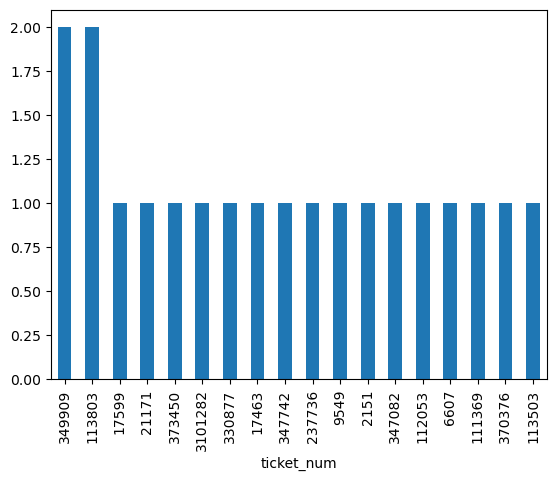

In [41]:
df['ticket_num'].value_counts().plot(kind='bar')